In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sys
from wave_approx import *
%load_ext autoreload
%autoreload 2

In [13]:
l = 8 # radius
deg_r = 10
v = 4
v = 4/deg_r*l
def activation_per_wave(l, d, v):
    tend = (2*l*np.sqrt(2)+2*d)/v
    dL =l*(np.sqrt(2)-1)
    activation = sp.integrate.quad(int_circle_chord, 0 + dL/v, tend-dL/v, args = (v, d, l))[0]
    return activation, tend
    
def center_area(l, d):
    mid = iint_circle_chord(l, l)
    a = (iint_circle_chord(l+d/2, l) - mid)*2
    e = np.pi*np.power(d/2, 2)
    return a, e
    
a1, t1 = activation_per_wave(l, 2, v)
a2, t2 = activation_per_wave(l, 3, v)
a3, t3 = activation_per_wave(l, 4, v)
a4, t4 = activation_per_wave(l, 5, v)
a5, t5 = activation_per_wave(l, 6, v)

w0 = a1/np.array([a1, a2, a3, a4, a5]) # total activation per wave
w1 = (a1/t1)/np.array([a1/t1, a2/t2, a3/t3, a4/t4, a5/t5]) # activation per sec
t = np.array([t1,t2,t3,t4,t5])

print(f'activatoin: {w0}')
print(f'activation/t: {w1}')
print(f't: {t}')

activatoin: [1.         0.66666667 0.5        0.4        0.33333333]
activation/t: [1.         0.71674037 0.57511055 0.49013266 0.43348074]
t: [ 8.32106781  8.94606781  9.57106781 10.19606781 10.82106781]


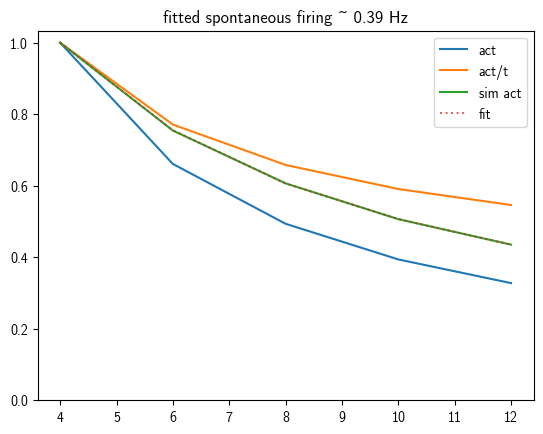

In [32]:
w2 = np.array([1, 0.7543475, 0.6066431, 0.5065616, 0.4352888])
x = np.array([4, 6, 8, 10, 12], dtype = float)
plt.plot(x, np.array([w0, w1, w2]).T, label = ['act', 'act/t', 'sim act'])
plt.ylim(bottom = 0)
#fitting: w0 = (w2 + spont*t)/(spont*t)
def f(x, spont):
    l = 8 # radius
    v = 3.2
    t = (2*l + 2*x)/v
    if hasattr(t, '__len__'):
        activation = np.array([sp.integrate.quad(int_circle_chord, 0, t[i], args = (v, x[i], l))[0] for i in range(len(t))])
    else:
        activation = sp.integrate.quad(int_circle_chord, 0, t, args = (v, x, l))[0]
    t0 = (2*l + 2*4)/v
    activation0 = sp.integrate.quad(int_circle_chord, 0, t0, args = (v, 4, l))[0]
    return (activation0 + spont*t0)/(activation + spont*t)
spont, _ = sp.optimize.curve_fit(f, x, w2, bounds = (0, np.inf))
plt.plot(x, f(x, *spont), ':', alpha = 0.7, label = 'fit')
plt.title(f'fitted spontaneous firing ~ {spont[0]/(np.pi*l*l):.2f} Hz')
plt.legend()